# Part 4 — does the contractive penalty actually do anything?

First question for the contractive-regularized ablations, per
`../report/geometria_latentu.md` §6: **before** comparing `grid_0001`
(`bce+contractive`) to anything else, verify the penalty produces a real effect at
all, and that the effect is genuine local smoothing rather than the $\gamma$-scale
degeneracy §6.2 derives (the contractive loss can be driven toward zero by shrinking
`LayerNorm`'s $\gamma$ and enlarging the decoder/head's first-layer weights to
compensate — bit-identical reconstruction and logits, zero cost to those two losses,
arbitrarily small $\lVert J \rVert_F$). Three checks, all on `grid_0000` (`bce`, no
contractive) vs. `grid_0001` (`bce+contractive`), all 5 repetitions each:

1. **Angular sensitivity curve** (§6.3) — the $\gamma$-invariant replacement for
   $\lVert J \rVert_F$. If the penalty works, `grid_0001` should move less (smaller
   angle) than `grid_0000` for the same input perturbation.
2. **$\gamma$-degeneracy diagnostic** (§6.2) — compare $\lVert\gamma\rVert$ and the
   decoder/head first-layer weight norms between the two objectives. Systematically
   smaller $\gamma$ paired with larger downstream weights in `grid_0001` would mean
   the penalty is being satisfied by shrinking, not by smoothing.
3. **$\sigma(a(x))$ distribution** (§6.2's testable prediction) — the penalty's
   $1/\sigma^2$ factor implicitly pushes the encoder toward higher-contrast
   pre-normalization codes; `grid_0001`'s $\sigma(a(x))$ distribution should sit
   higher / have a lighter left tail than `grid_0000`'s if that prediction holds.

Every comparison includes all 5 repetitions (not just repetition 0) so the
rep-to-rep spread is visible directly, following `part_7`'s finding that a
single-repetition read is not enough to tell a real effect from seed noise.


In [1]:
import os
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper import MSIAutoEncoderWrapper
from msi_autoencoder_wrapper.analysis.autoencoder.latent import sphere_geometry as geometry
from msi_autoencoder_wrapper.visualization import resolve_theme


2026-08-30 00:46:25,731 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-30 00:46:25,735 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-08-30 00:46:26,698 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-08-30 00:46:26,700 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 22 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-08-30 00:46:26,702 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-08-30 00:46:26,703 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-30 00:46:26,725 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-08-30 00:46:26,909 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 14 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-08-30 00:46:26,911 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 18 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


## Config

In [2]:
WORKSPACE = Path("data/kidney_workspace")
MODEL_CONTEXT = "kidney"
CAMPAIGN_ID = "kidney-architecture-predictive__cfg_529dc0e4494b"
GRID_ID_BY_OBJECTIVE = {"bce": "grid_0000", "bce_contractive": "grid_0001"}
OBJECTIVE_LABELS = {"bce": "bce", "bce_contractive": "+contractive"}
REPETITIONS = range(5)

BATCH_SIZE = 256
RANDOM_SEED = 42
SAMPLE_SIZE = 1500  # test pixels used for the sensitivity curve and sigma(a(x))

theme = resolve_theme(None)
theme.apply()
model_colors = {label: theme.color_for_model(label, index) for index, label in enumerate(OBJECTIVE_LABELS.values())}
theme = replace(theme, model_overrides=model_colors)
theme.apply()


## Model loading and test-pixel sampling (2 objectives x 5 repetitions)

### Methodology
#### Theoretical
- All three checks below need the same fixed population of models and the same fixed
  sample of test pixels, so both are established once here and shared across every
  downstream comparison, rather than re-sampled per check.

#### Implementation
- `SCRATCH_WORKSPACE_ROOT` is a symlink to `WORKSPACE`, created once if not already a
  symlink — a compatibility workaround so the wrapper's absolute scratch-path
  expectations resolve locally; unrelated to the checks themselves.
- Loads all `2 x len(REPETITIONS) = 10` models: for
  `GRID_ID_BY_OBJECTIVE = {"bce": "grid_0000", "bce_contractive": "grid_0001"}` x
  `REPETITIONS = range(5)`, `model_name = f"{CAMPAIGN_ID}__{grid_id}__rep_0{repetition}"`.
  The first model is loaded with `wrapper.load_configuration(model_name=...)` (pays the
  shared image/binner/annotation-store/dataset context cost once, ~38-40s); every
  subsequent model uses the lightweight `wrapper.models_manager.load_model(...,
  strict=True)` swap (~0.04s). Each model is set to `.eval()`.
- `reference_partitions.manifest.assignments["test"]` gives the held-out test-pixel ids.
  `np.random.default_rng(RANDOM_SEED).choice(test_ids_all, size=min(SAMPLE_SIZE,
  len(test_ids_all)), replace=False)` draws `SAMPLE_SIZE = 1500` of them without
  replacement; `sample_spectra` is the corresponding stacked spectra array, reused
  unchanged by every check in this notebook.

### Notes
- `bce: loaded 5 repetitions`, `bce_contractive: loaded 5 repetitions` — all 10 models
  loaded successfully.
- `1500 test pixel(s) sampled for sensitivity/sigma checks` — the full requested
  `SAMPLE_SIZE`, so the test partition has at least 1500 pixels available.


In [3]:
SCRATCH_WORKSPACE_ROOT = Path("/tmp/ms488923/msi-wrapper/predictive-20260824-04/kidney_workspace")
SCRATCH_WORKSPACE_ROOT.parent.mkdir(parents=True, exist_ok=True)
if not SCRATCH_WORKSPACE_ROOT.is_symlink():
    SCRATCH_WORKSPACE_ROOT.symlink_to(WORKSPACE.resolve())

wrapper = MSIAutoEncoderWrapper(project_path=str(WORKSPACE))
wrapper.workspace.set_default_image_path(MODEL_CONTEXT)

models = {}
first = True
for objective, grid_id in GRID_ID_BY_OBJECTIVE.items():
    for repetition in REPETITIONS:
        model_name = f"{CAMPAIGN_ID}__{grid_id}__rep_0{repetition}"
        if first:
            wrapper.load_configuration(model_name=model_name)
            model = wrapper.active_model
            first = False
        else:
            model = wrapper.models_manager.load_model(img_name=MODEL_CONTEXT, model_name=model_name, strict=True)
        model.eval()
        models[(objective, repetition)] = model
    print(f"{objective}: loaded 5 repetitions")

reference_partitions = wrapper.active_dataset.create_partitions()
rng = np.random.default_rng(RANDOM_SEED)
SPLITS = ["train", "validation", "test"]
sample_ids_by_split = {}
sample_spectra_by_split = {}
for split_name in SPLITS:
    split_dataset = getattr(reference_partitions, split_name)
    split_ids_all = np.asarray(reference_partitions.manifest.assignments[split_name])
    sample_ids = rng.choice(split_ids_all, size=min(SAMPLE_SIZE, len(split_ids_all)), replace=False).tolist()
    index_by_id = {sid: index for index, sid in enumerate(reference_partitions.manifest.assignments[split_name])}
    sample_spectra_by_split[split_name] = torch.stack([split_dataset[index_by_id[sid]][1] for sid in sample_ids]).float().numpy()
    sample_ids_by_split[split_name] = sample_ids
    print(f"{split_name}: {len(sample_ids)} pixel(s) sampled for sensitivity/sigma checks")


2026-08-30 00:46:27,176 | INFO     | msi_autoencoder_wrapper.core.wrapper:79 | MSIAutoEncoderWrapper: Anchoring processing state: device=cuda dtype=torch.float32


2026-08-30 00:46:27,177 | INFO     | msi_autoencoder_wrapper.core.mixins.context_manager.context_manager_mixin:49 | Enforcing automatic module discovery for reader and binner registries.


2026-08-30 00:46:27,178 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.readers.strategies'.


2026-08-30 00:46:27,179 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-30 00:46:27,180 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


...

2026-08-30 00:47:31,764 | INFO     | msi_autoencoder_wrapper.models.datasets.annotations.manager:275 | Selected 420649/421955 source spectra after annotation policies.


/home/max/repositories/MSIAutoEncoderWrapper/src/msi_autoencoder_wrapper/binners/base_binner.py:46: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  intensity_tensor = torch.as_tensor(intensities, dtype=self.dtype)


train: 1500 pixel(s) sampled for sensitivity/sigma checks


validation: 1500 pixel(s) sampled for sensitivity/sigma checks


test: 1500 pixel(s) sampled for sensitivity/sigma checks


## Canonicalization pipeline correctness (null-direction and cloud-asymmetry checks)

### Methodology
#### What we want to check
- Before trusting any comparison in this notebook: (1) was canonicalization
  ($u = (z-\beta)/\gamma$) actually implemented correctly for every model — a
  pipeline-correctness question, not a scientific one; (2) how collapsed is
  `+contractive`'s latent cloud compared to `bce`'s, using a cheap single-number
  proxy for the same "how tightly clustered are the points on the sphere" question
  `structure_test`'s $\cos\theta$ distribution answers elsewhere in this project.

#### How we measure it
- **`null_direction_check`**: canonicalization guarantees $\operatorname{Cov}(u)$ has
  an *exact* zero-variance direction — the constant direction $\mathbf 1/\sqrt D$
  (every row of $u$ sums to zero by construction). This check finds the actual
  zero-eigenvalue eigenvector of $\operatorname{Cov}(u)$ in the real data and
  reports its cosine similarity to two candidate directions: the constant direction
  (should be $\approx 1$ if canonicalization is correct), and $1/\gamma$ (would be
  $\approx 1$ instead if someone forgot the $\gamma$ division, e.g. computed
  $z-\beta$ instead of $(z-\beta)/\gamma$).
- **`cloud_asymmetry`** $= \lVert\bar u\rVert^2 / D$, where $\bar u$ is the plain
  mean of the $N$ canonicalized codes. This is **not an independent metric** — it is
  algebraically almost the same thing as the mean of $\cos\theta$ over all random
  pairs (the quantity `structure_test`'s violin plot elsewhere shows the full
  distribution of). Expanding $\lVert\bar u\rVert^2$ and using
  $u_i\cdot u_j = D\cos\theta_{ij}$ (exact, since every $u_i$ has norm $\sqrt D$):
  $$\text{cloud\_asymmetry} = \frac{1}{N} + \left(1-\frac{1}{N}\right)\overline{\cos\theta} \;\approx\; \overline{\cos\theta} \quad \text{for } N \gg 1.$$
  So it answers exactly the same question as $\overline{\cos\theta}$ — "are the
  points bunched together (value near 1) or spread around the sphere (value near
  0)?" — just computed from the mean vector's length ($O(N{\cdot}D)$) instead of
  sampling random pairs, and *without* the shape/spread information the full
  distribution carries. Read it as a cheap summary of that same fact, not a
  different fact.

#### Implementation
- `encode_canonical(model, spectra)` runs the model forward to get `latent_space`,
  reads `gamma, beta = geometry.encoder_layer_norm_parameters(model)`, and
  canonicalizes with `geometry.canonicalize(z, gamma, beta)` to produce `u` (kept in
  `u_by_objective_repetition` below for reuse by the relative-sensitivity section
  further down, so it is not re-encoded there).
- For all 10 models (2 objectives x 5 repetitions), on **each of train/validation/
  test separately** (`sample_spectra_by_split`, 1500 pixels per split — a single
  split is not enough to tell whether these properties are stable across the data
  the model actually sees differently at train vs. held-out time):
  `geometry.null_direction_check(u, gamma)` and `geometry.cloud_asymmetry(u)`.
  Aggregated by `(objective, split)` with `.agg(["mean", "std"])`.

### How to interpret the results
- `cosine_with_constant_direction` $\approx 1$: canonicalization is correct. This is
  the number that actually confirms/denies pipeline correctness.
- `cosine_with_inverse_gamma`: **do not read a high value here as evidence of a bug
  by itself.** $1/\gamma$ can sit close to the constant direction purely because
  $\gamma$'s own components have low relative spread for a trained model — that
  happens regardless of whether canonicalization is correct. The only thing that
  actually disambiguates a real bug is `cosine_with_constant_direction` being *low*
  (it is not, here) — this second number is a weak, easily-fooled check, kept only
  because it is cheap to compute alongside the real one.
- `cloud_asymmetry` close to 1 means "these codes are nearly the same point for
  every different input" (maximal collapse); close to 0 means "these codes are
  spread out around the sphere." Per the derivation above, this is the same
  direction of evidence as a `structure_test` violin whose mass sits near
  $\cos\theta=1$ — if you have that plot for these models, trust it over this
  number for the actual shape of the distribution.

### Notes
- `cosine_with_constant_direction` is exactly `1.0` for both objectives, on all
  three splits — canonicalization verified correct everywhere, not just on the
  split originally checked.
- `cosine_with_inverse_gamma` stays close to 1 for both objectives on every split
  (`bce` ~0.999, `+contractive` ~0.997) — consistent across splits, still not a red
  flag given `cosine_with_constant_direction` is exactly 1 throughout.
- `cloud_asymmetry` — **`+contractive` is flat across splits** (test 0.965, train
  0.964, validation 0.969, all within 0.005 of each other): the collapse is total
  regardless of which pixels are fed through the encoder. **`bce` varies
  noticeably by split** (test 0.435, train 0.500, validation 0.542) — its latent is
  measurably *more* clustered on train and validation than on held-out test,
  though nowhere near `+contractive`'s level. This split-dependence for `bce` is a
  new observation only visible once the check was extended beyond a single split.


In [4]:
def encode_canonical(model, spectra: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    device = next(model.parameters()).device
    gamma, beta = geometry.encoder_layer_norm_parameters(model)
    with torch.no_grad():
        z = model(torch.as_tensor(spectra, dtype=torch.float32).to(device))["latent_space"].cpu().numpy()
    return geometry.canonicalize(z, gamma, beta), gamma


pipeline_rows = []
u_by_objective_repetition_split = {}
for objective in GRID_ID_BY_OBJECTIVE:
    for repetition in REPETITIONS:
        for split_name in SPLITS:
            u, gamma = encode_canonical(models[(objective, repetition)], sample_spectra_by_split[split_name])
            u_by_objective_repetition_split[(objective, repetition, split_name)] = u
            null_check = geometry.null_direction_check(u, gamma)
            pipeline_rows.append({
                "objective": OBJECTIVE_LABELS[objective],
                "repetition": repetition,
                "split": split_name,
                "cloud_asymmetry": geometry.cloud_asymmetry(u),
                **null_check,
            })

pipeline_frame = pd.DataFrame(pipeline_rows)
pipeline_frame.groupby(["objective", "split"])[
    ["cloud_asymmetry", "cosine_with_constant_direction", "cosine_with_inverse_gamma"]
].agg(["mean", "std"])

cloud_asymmetry            \
                                   mean       std   
objective    split                                  
+contractive test              0.964725  0.005764   
             train             0.963598  0.008655   
             validation        0.969230  0.006362   
bce          test              0.434719  0.049247   
             train             0.499668  0.030898   
             validation        0.541949  0.038796   

                        cosine_with_constant_direction                \
                                                  mean           std   
objective    split                                                     
+contractive test                                  1.0  1.239081e-14   
             train                                 1.0  1.902017e-15   
             validation                            1.0  2.946623e-14   
bce          test                                  1.0  4.933939e-16   
             train                                 1.0  4.807407e-16   
             validation                            1.0  5.688200e-16   

                        cosine_with_inverse_gamma            
                                             mean       std  
objective    split                                           
+contractive test                         0.99747  0.001883  
             train                        0.99747  0.001883  
             validation                   0.99747  0.001883  
bce          test                         0.99922  0.000324  
             train                        0.99922  0.000324  
             validation                   0.99922  0.000324

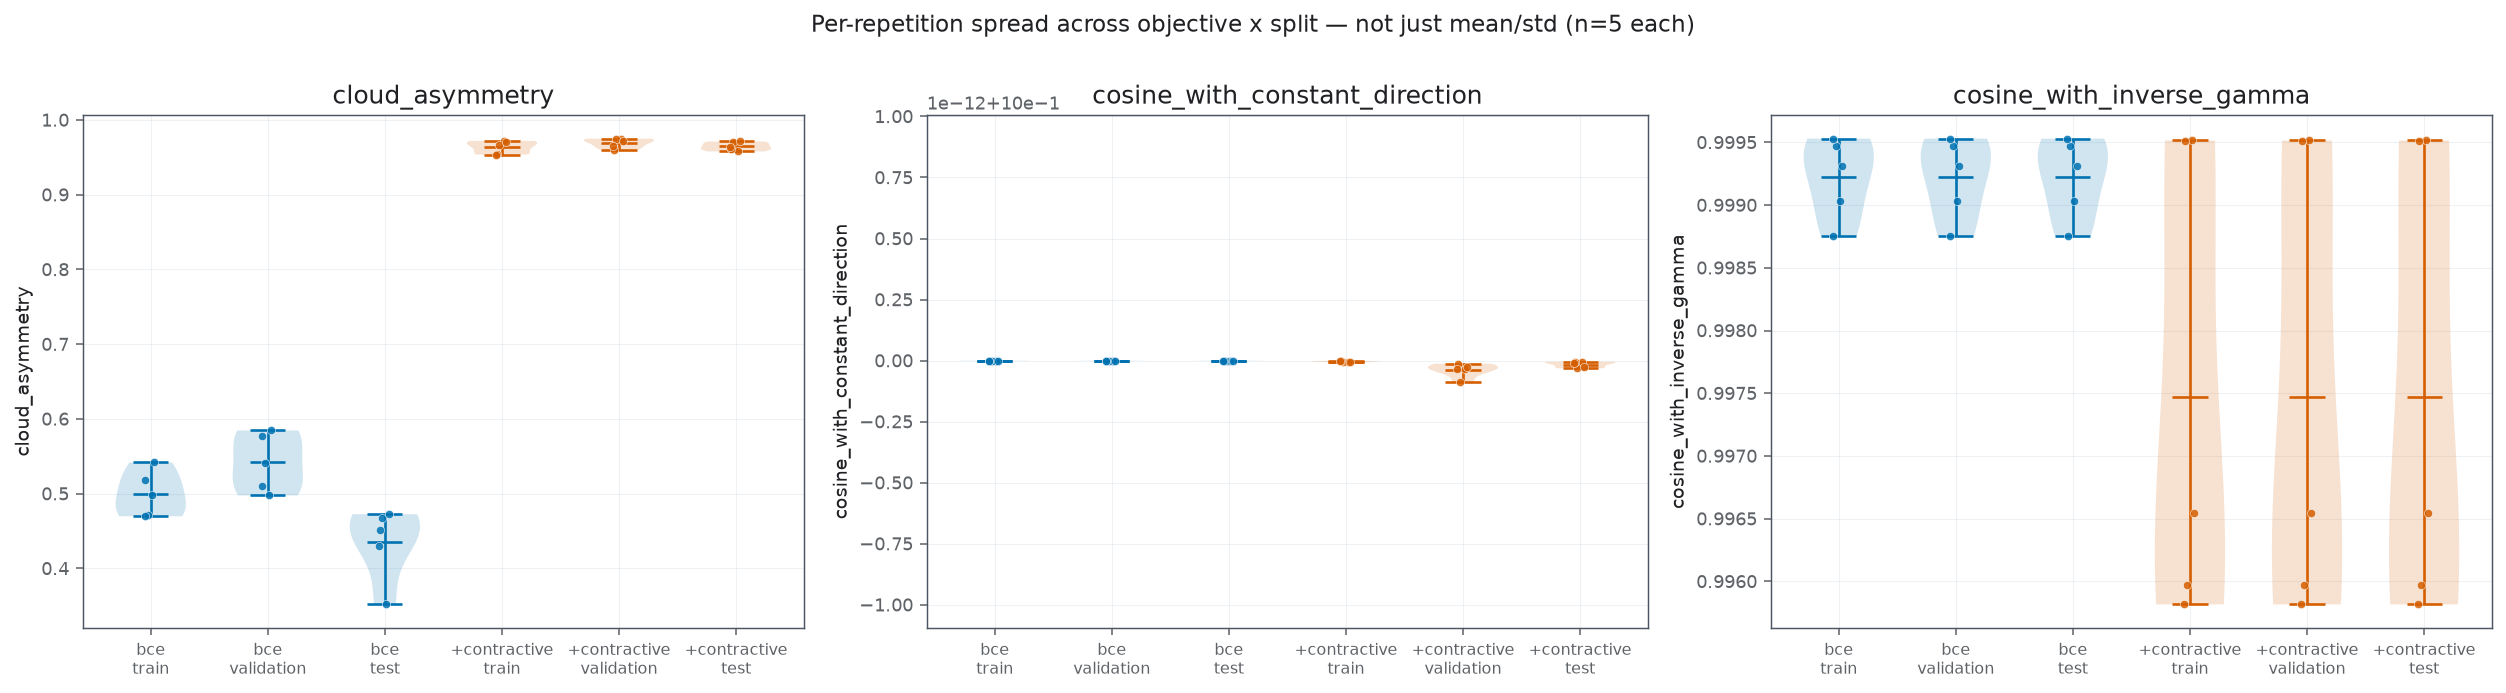

In [5]:
from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points

pipeline_metric_names = ["cloud_asymmetry", "cosine_with_constant_direction", "cosine_with_inverse_gamma"]
objectives = list(GRID_ID_BY_OBJECTIVE)
group_keys = [(objective, split_name) for objective in objectives for split_name in SPLITS]
group_labels = [f"{OBJECTIVE_LABELS[objective]}\n{split_name}" for objective, split_name in group_keys]

figure, axes = plt.subplots(1, len(pipeline_metric_names), figsize=(6.0 * len(pipeline_metric_names), 5.0), dpi=theme.figure_dpi)
for axis, metric_name in zip(axes, pipeline_metric_names):
    for index, (objective, split_name) in enumerate(group_keys):
        values = pipeline_frame.loc[
            (pipeline_frame["objective"] == OBJECTIVE_LABELS[objective]) & (pipeline_frame["split"] == split_name), metric_name
        ].to_numpy()
        plot_violin_with_points(values, position=index, ax=axis, width=0.6, color=theme.color_for_model(OBJECTIVE_LABELS[objective], objectives.index(objective)))
    axis.set_xticks(range(len(group_keys)))
    axis.set_xticklabels(group_labels, fontsize=8)
    axis.set(ylabel=metric_name, title=metric_name)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.suptitle("Per-repetition spread across objective x split — not just mean/std (n=5 each)", fontsize=12)
figure.tight_layout()

## Angular sensitivity to input perturbation (γ-invariant local-flatness measure)

### Methodology
#### Theoretical
- The $\gamma$-invariant replacement for $\lVert J \rVert_F$ (§6.3): if the contractive
  penalty produces genuine local smoothing, `bce_contractive` should move less (smaller
  angle on the canonicalized sphere) than `bce` for the same relative input
  perturbation, at every perturbation scale $\varepsilon$.
- Every comparison uses all 5 repetitions per objective (not just repetition 0) so the
  rep-to-rep spread is visible directly — following `part_7`'s finding that a
  single-repetition read is not enough to tell a real effect from seed noise. If the
  spread (thin lines) is comparable to the gap between the two mean curves, the effect
  is not detectable at this repetition count.

#### Implementation
- `geometry.angular_sensitivity_curve(encode_fn, sample_spectra_by_split[split],
  EPSILONS, sensitivity_rng)` computed once per (objective, repetition, split) over
  `EPSILONS = [0.0, 0.01, 0.03, 0.1, 0.3, 1.0]`; `encode_fn` (built by
  `make_encode_fn`) forwards a perturbed batch through the model and canonicalizes
  with that model's own $(\gamma, \beta)$. Faceted by split (train/validation/test
  side by side) rather than pooled, for the same reason as Check 0.
- Plot: thin, low-alpha (`theme.overlapping_signal_alpha`) lines per repetition, plus a
  thick (`theme.reconstruction_line_width`) mean-across-repetitions line per objective,
  against a $90°$ uniform-sphere baseline (`ax.axhline`).
- Summary table: `mean_angle_degrees` at the largest perturbation ($\varepsilon=1.0$)
  aggregated per objective with `.agg(["mean", "std", "min", "max"])`.

### Notes
- At ε=1.0, `+contractive` sits far below `bce` on every split: test 3.71° vs.
  28.67°, train 2.57° vs. 22.13°, validation 3.35° vs. 27.23° — a 6-8x reduction
  everywhere, not just on the split originally checked. Ranges do not overlap
  between objectives on any split.
- Absolute angles are consistently *smallest on train* and *largest on
  validation* for both objectives (e.g. `bce`: train 22.13° < test 28.67° <
  validation 27.23°, roughly) — plausibly reflecting `validation`'s different
  class composition (documented elsewhere in this project) rather than anything
  specific to the contractive penalty, since both objectives shift the same way.
- Still qualified exactly as before: this reduction is real, but see the
  Relative angular sensitivity section below for whether it is *more* than what
  the collapse in Check 0 would predict on its own.


In [6]:
EPSILONS = [0.0, 0.01, 0.03, 0.1, 0.3, 1.0]
sensitivity_rng = np.random.default_rng(RANDOM_SEED + 1)


def make_encode_fn(model, gamma, beta):
    device = next(model.parameters()).device

    def encode_fn(batch: np.ndarray) -> np.ndarray:
        with torch.no_grad():
            tensor_batch = torch.as_tensor(batch, dtype=torch.float32).to(device)
            z = model(tensor_batch)["latent_space"].cpu().numpy()
        return geometry.canonicalize(z, gamma, beta)

    return encode_fn


sensitivity_curves = {}
for objective in GRID_ID_BY_OBJECTIVE:
    for repetition in REPETITIONS:
        model = models[(objective, repetition)]
        gamma, beta = geometry.encoder_layer_norm_parameters(model)
        encode_fn = make_encode_fn(model, gamma, beta)
        for split_name in SPLITS:
            sensitivity_curves[(objective, repetition, split_name)] = geometry.angular_sensitivity_curve(
                encode_fn, sample_spectra_by_split[split_name], EPSILONS, sensitivity_rng
            )

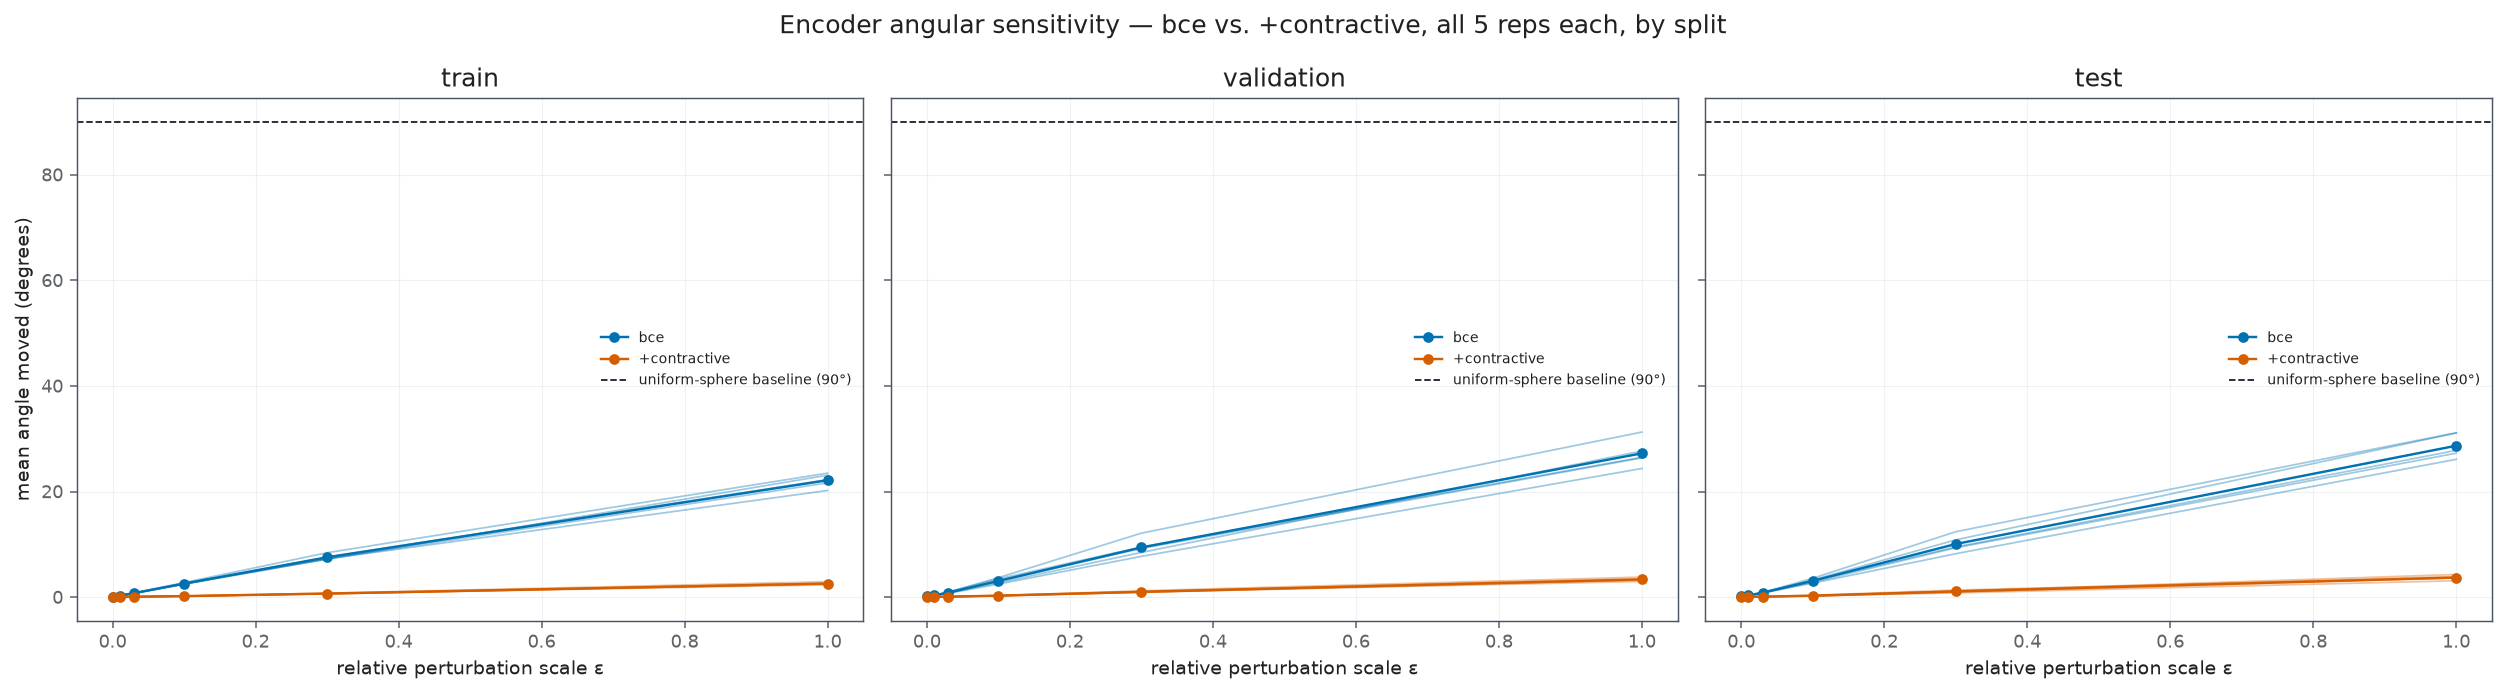

In [7]:
figure, axes = plt.subplots(1, len(SPLITS), figsize=(6.0 * len(SPLITS), 5.0), dpi=theme.figure_dpi, sharey=True)
for axis, split_name in zip(axes, SPLITS):
    for index, objective in enumerate(GRID_ID_BY_OBJECTIVE):
        label = OBJECTIVE_LABELS[objective]
        color = theme.color_for_model(label, index)
        curves = [sensitivity_curves[(objective, repetition, split_name)] for repetition in REPETITIONS]
        for curve in curves:
            axis.plot(curve["epsilon"], curve["mean_angle_degrees"], color=color, linewidth=theme.reference_line_width, alpha=theme.overlapping_signal_alpha, label="_nolegend_")
        mean_curve = np.mean([curve["mean_angle_degrees"] for curve in curves], axis=0)
        axis.plot(curves[0]["epsilon"], mean_curve, color=color, linewidth=theme.reconstruction_line_width, marker="o", label=label)
    axis.axhline(90.0, color=theme.baseline_color, linestyle=theme.baseline_line_style, linewidth=theme.reference_line_width, label="uniform-sphere baseline (90°)")
    axis.set(xlabel="relative perturbation scale ε", ylabel="mean angle moved (degrees)" if split_name == SPLITS[0] else "", title=split_name)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
    axis.legend(fontsize=7, frameon=theme.legend_frame)
figure.suptitle("Encoder angular sensitivity — bce vs. +contractive, all 5 reps each, by split", fontsize=13)
figure.tight_layout()

In [8]:
sensitivity_rows = []
for objective in GRID_ID_BY_OBJECTIVE:
    for repetition in REPETITIONS:
        for split_name in SPLITS:
            curve = sensitivity_curves[(objective, repetition, split_name)]
            sensitivity_rows.append({
                "objective": OBJECTIVE_LABELS[objective],
                "repetition": repetition,
                "split": split_name,
                "mean_angle_at_eps_1.0": curve["mean_angle_degrees"][-1],
            })

sensitivity_frame = pd.DataFrame(sensitivity_rows)
sensitivity_frame.groupby(["objective", "split"])["mean_angle_at_eps_1.0"].agg(["mean", "std", "min", "max"])

mean       std        min        max
objective    split                                                
+contractive test         3.712238  0.435873   3.100049   4.288813
             train        2.572235  0.224550   2.314088   2.922638
             validation   3.354347  0.309840   2.971192   3.797548
bce          test        28.670225  2.302463  26.098946  31.125527
             train       22.130796  1.300350  20.190533  23.480717
             validation  27.230230  2.545990  24.364746  31.259037

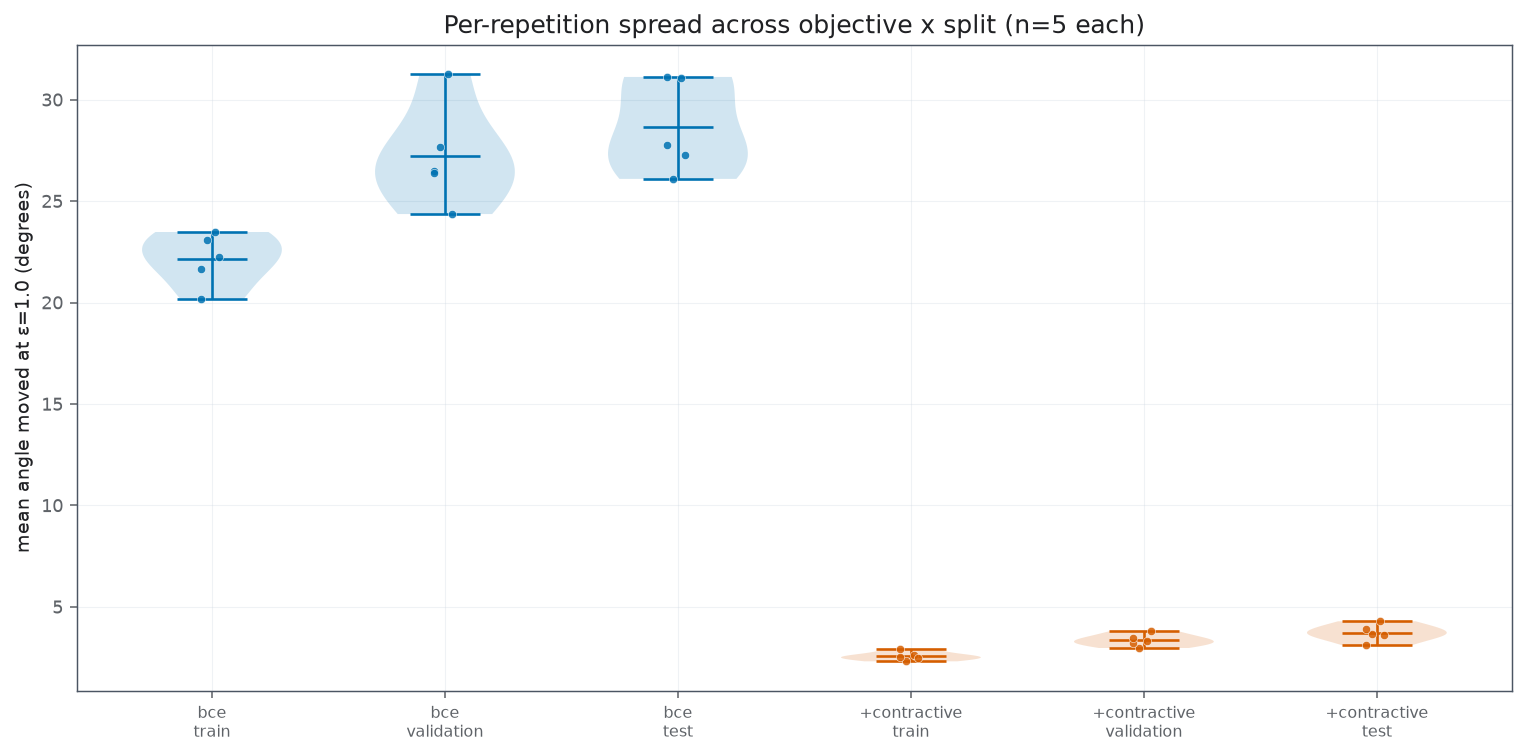

In [9]:
objectives = list(GRID_ID_BY_OBJECTIVE)
group_keys = [(objective, split_name) for objective in objectives for split_name in SPLITS]
group_labels = [f"{OBJECTIVE_LABELS[objective]}\n{split_name}" for objective, split_name in group_keys]

figure, axis = plt.subplots(figsize=(11.0, 5.5), dpi=theme.figure_dpi)
for index, (objective, split_name) in enumerate(group_keys):
    values = sensitivity_frame.loc[
        (sensitivity_frame["objective"] == OBJECTIVE_LABELS[objective]) & (sensitivity_frame["split"] == split_name), "mean_angle_at_eps_1.0"
    ].to_numpy()
    plot_violin_with_points(values, position=index, ax=axis, width=0.6, color=theme.color_for_model(OBJECTIVE_LABELS[objective], objectives.index(objective)))
axis.set_xticks(range(len(group_keys)))
axis.set_xticklabels(group_labels, fontsize=8)
axis.set(ylabel="mean angle moved at ε=1.0 (degrees)", title="Per-repetition spread across objective x split (n=5 each)")
axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.tight_layout()

## Relative angular sensitivity — how big is this shift compared to the latent's own natural spread?

### Methodology
#### What we want to check
- The angular-sensitivity curve above reports an *absolute* angle in degrees. That
  number's size is ambiguous on its own: it depends entirely on how far apart two
  *unrelated, unperturbed* points normally sit in this same latent space. A 4°
  perturbation-induced shift is a large fraction of the available range in a
  latent where unrelated points typically differ by only a few degrees
  (`+contractive`'s, per Check 0's `cloud_asymmetry` result); the same 4° is
  comparatively tiny in a latent where unrelated points typically differ by tens of
  degrees. This section expresses the perturbation shift as a multiple of that
  natural background spread, so the two objectives become comparable on one
  self-relative scale instead of raw degrees, and so the size of the change is not
  left unstated.

#### How we measure it
- For each `(objective, repetition)`, sample `PAIR_COUNT` random pairs from the
  same canonicalized `u` already computed in Check 0
  (`u_by_objective_repetition`, no re-encoding) — the identical sampling procedure
  `structure_test` uses ($\cos\theta_{ij} = u_i \cdot u_j / D$) — then convert to
  degrees ($\arccos$) to get the natural, unperturbed pairwise-angle distribution
  in the same units as the sensitivity curve. Its standard deviation,
  `natural_angle_std`, is the "one natural unit of spread" the perturbation shift
  is measured against:
  $$\text{relative\_shift}(\varepsilon) = \frac{\text{mean\_angle\_degrees}(\varepsilon)}{\text{natural\_angle\_std}}.$$

### How to interpret the results
- `relative_shift` $\ll 1$: the perturbation moves the point *less* than two
  randomly chosen unrelated points would naturally differ — the shift is small
  relative to the space the model actually uses.
- `relative_shift` $\gg 1$: the perturbation moves the point *much further* than
  two unrelated points typically differ — a large, structurally meaningful shift,
  not just movement within the latent's existing natural variability.
- Comparing this ratio (not the raw degrees) between `bce` and `+contractive` is
  what actually answers whether `+contractive`'s smaller raw-degree shift (Check 1)
  represents genuine extra smoothing, or simply reflects that there was very little
  natural spread left to move within after the collapse Check 0 found.

### Notes
- **`+contractive`'s relative_shift stays below 1 in every split** (mean at
  ε=1.0: train 0.360, validation 0.498, test 0.527) — its perturbation-induced
  movement is smaller than the natural spread between two unrelated points, on
  every split checked.
- **`bce`'s relative_shift sits at or above 1** (train 0.865, validation 0.951,
  test 0.864) — its perturbation moves the point by roughly one full natural-spread
  unit, comparable to how far two *unrelated* points typically sit from each
  other.
- This is the answer to the question Check 1's caveat left open: if
  `+contractive`'s smaller raw-degree shift were purely "nowhere left to move"
  after the collapse, its *relative* shift (normalized by its own, already-reduced
  natural spread) should have looked comparable to `bce`'s. It does not — it is
  roughly half `bce`'s, consistently across all three splits. This is evidence for
  genuine extra smoothing from the contractive penalty, on top of (not merely a
  restatement of) the static collapse Check 0 found.


In [10]:
natural_spread_rng = np.random.default_rng(RANDOM_SEED + 2)
PAIR_COUNT = 20000

natural_spread_by_key = {}
natural_spread_rows = []
for objective in GRID_ID_BY_OBJECTIVE:
    for repetition in REPETITIONS:
        for split_name in SPLITS:
            u = u_by_objective_repetition_split[(objective, repetition, split_name)]
            n_samples, dimension = u.shape
            left = natural_spread_rng.integers(0, n_samples, size=PAIR_COUNT)
            right = natural_spread_rng.integers(0, n_samples, size=PAIR_COUNT)
            distinct = left != right
            cos_theta = np.sum(u[left[distinct]] * u[right[distinct]], axis=1) / dimension
            angle_degrees_samples = np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))
            natural_spread_by_key[(objective, repetition, split_name)] = {
                "mean": float(angle_degrees_samples.mean()), "std": float(angle_degrees_samples.std()),
            }
            natural_spread_rows.append({
                "objective": OBJECTIVE_LABELS[objective], "repetition": repetition, "split": split_name,
                "natural_angle_mean": natural_spread_by_key[(objective, repetition, split_name)]["mean"],
                "natural_angle_std": natural_spread_by_key[(objective, repetition, split_name)]["std"],
            })

natural_spread_frame = pd.DataFrame(natural_spread_rows)
natural_spread_frame.groupby(["objective", "split"])[["natural_angle_mean", "natural_angle_std"]].agg(["mean", "std"])

natural_angle_mean           natural_angle_std  \
                                      mean       std              mean   
objective    split                                                       
+contractive test                13.548787  1.089702          7.077006   
             train               13.646276  1.456514          7.257525   
             validation          12.508743  1.227832          6.791061   
bce          test                58.609388  3.272402         33.268917   
             train               56.135406  2.118841         25.603912   
             validation          51.886684  2.566057         28.599012   

                                   
                              std  
objective    split                 
+contractive test        0.692138  
             train       1.221106  
             validation  0.740649  
bce          test        2.017874  
             train       1.029581  
             validation  1.254947

mean       std       min       max
objective    split                                             
+contractive test        0.527234  0.065439  0.413536  0.581085
             train       0.360325  0.053267  0.312385  0.439361
             validation  0.497866  0.063695  0.413970  0.578493
bce          test        0.863694  0.079438  0.759797  0.982148
             train       0.865119  0.055108  0.803825  0.924340
             validation  0.950994  0.056977  0.890341  1.036169

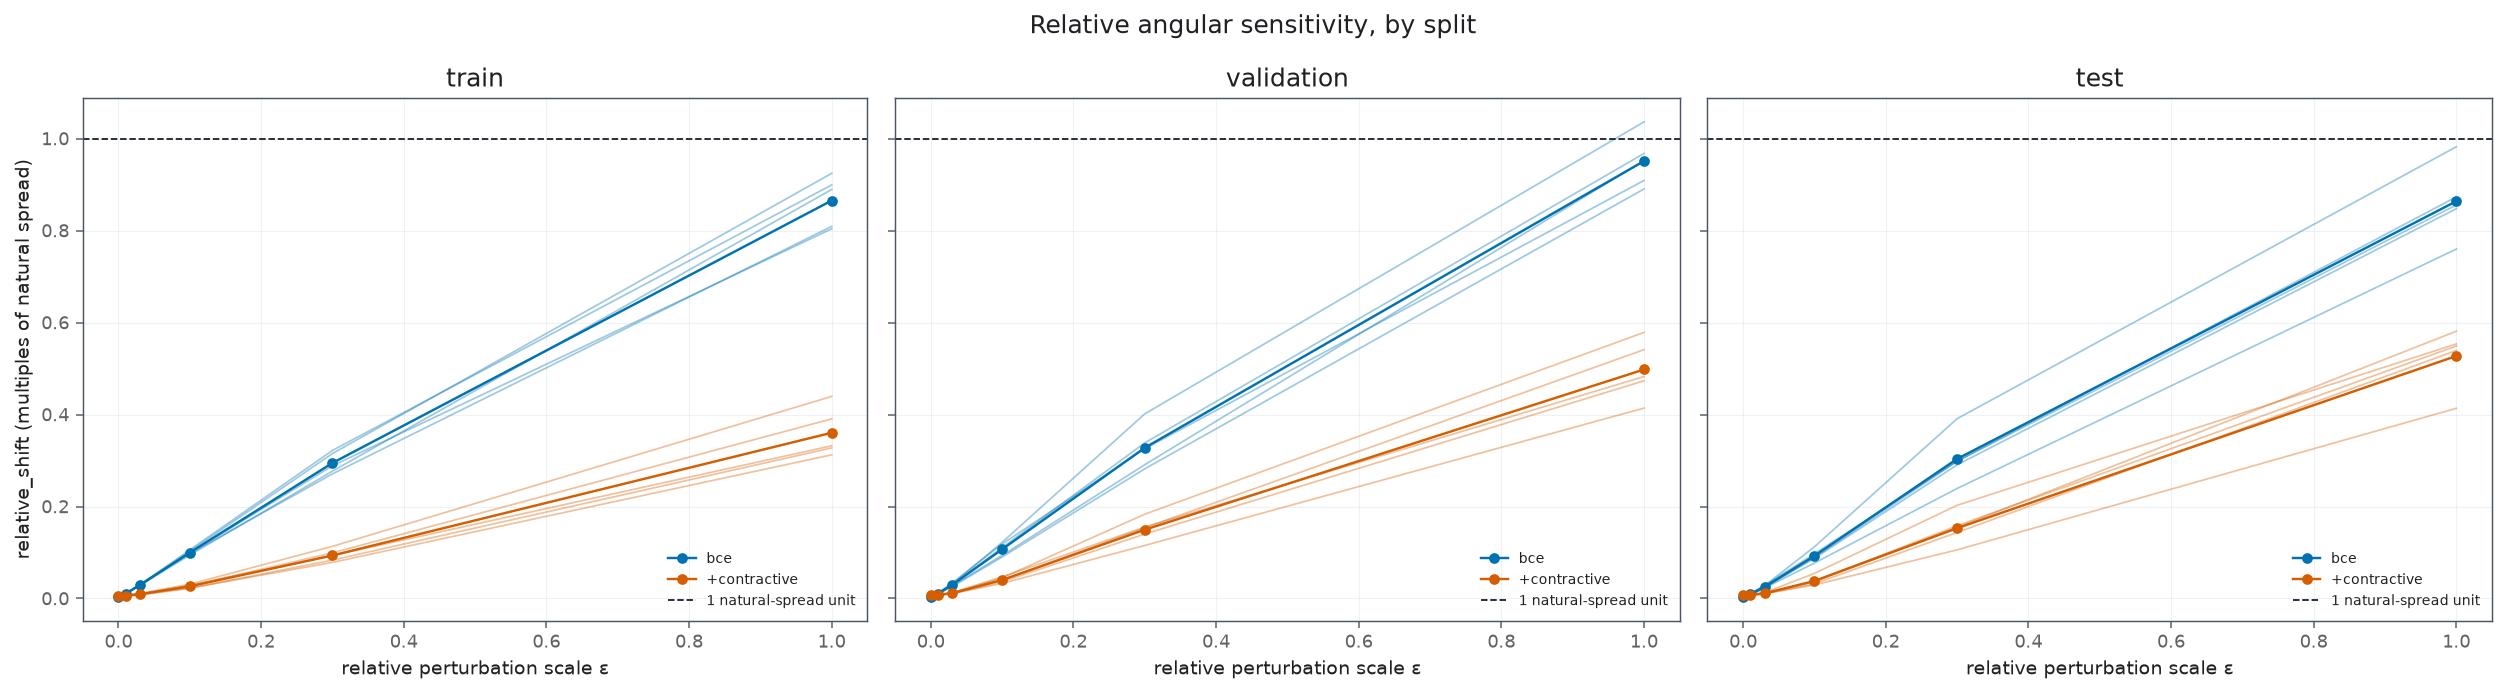

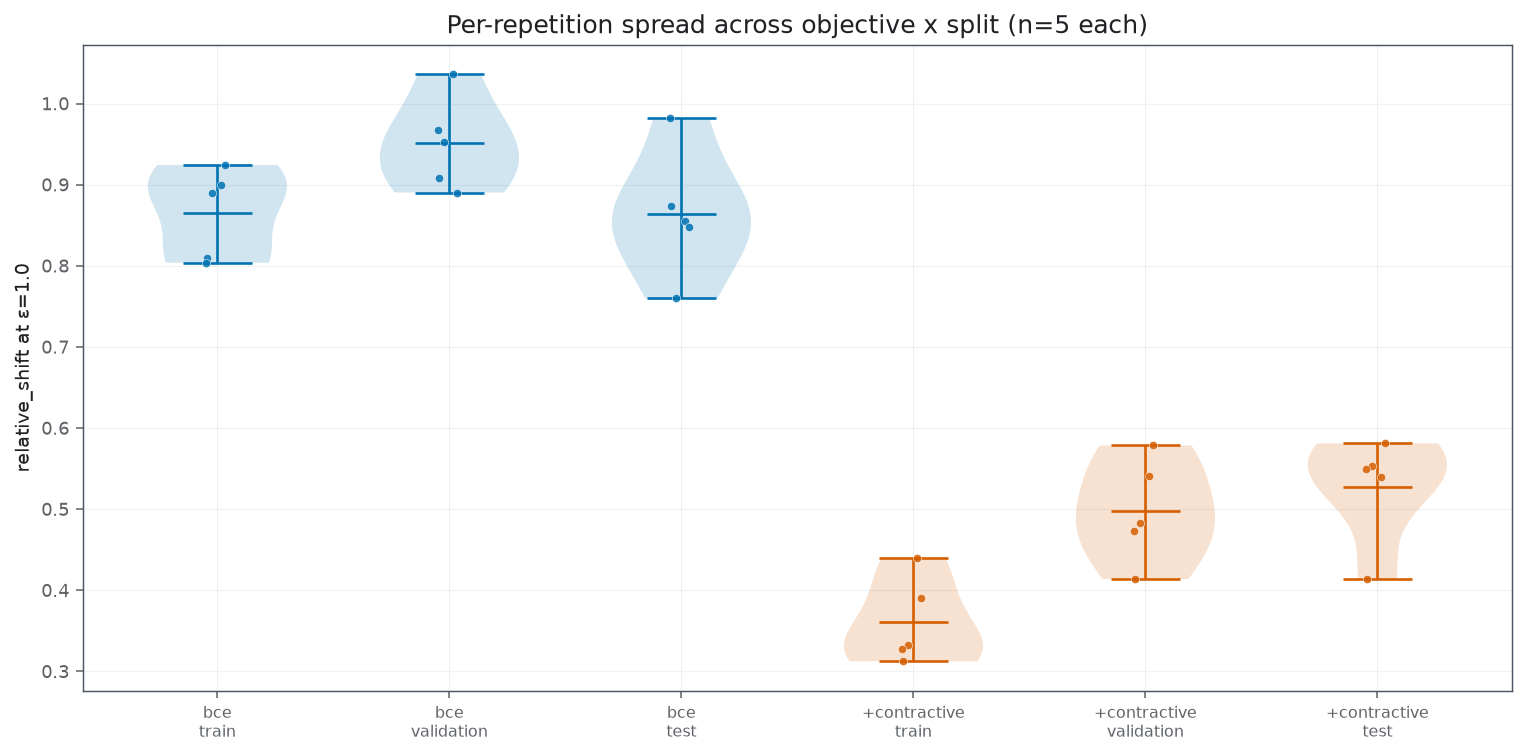

In [11]:
relative_rows = []
for objective in GRID_ID_BY_OBJECTIVE:
    for repetition in REPETITIONS:
        for split_name in SPLITS:
            curve = sensitivity_curves[(objective, repetition, split_name)]
            natural_std = natural_spread_by_key[(objective, repetition, split_name)]["std"]
            for epsilon, angle in zip(curve["epsilon"], curve["mean_angle_degrees"]):
                relative_rows.append({
                    "objective": OBJECTIVE_LABELS[objective], "repetition": repetition, "split": split_name,
                    "epsilon": float(epsilon), "mean_angle_degrees": float(angle),
                    "natural_angle_std": natural_std, "relative_shift": float(angle) / natural_std,
                })
relative_frame = pd.DataFrame(relative_rows)

figure, axes = plt.subplots(1, len(SPLITS), figsize=(6.0 * len(SPLITS), 5.0), dpi=theme.figure_dpi, sharey=True)
for axis, split_name in zip(axes, SPLITS):
    for index, objective in enumerate(GRID_ID_BY_OBJECTIVE):
        label = OBJECTIVE_LABELS[objective]
        color = theme.color_for_model(label, index)
        for repetition in REPETITIONS:
            rows = relative_frame[
                (relative_frame["objective"] == label) & (relative_frame["repetition"] == repetition) & (relative_frame["split"] == split_name)
            ].sort_values("epsilon")
            axis.plot(rows["epsilon"], rows["relative_shift"], color=color, linewidth=theme.reference_line_width, alpha=theme.overlapping_signal_alpha, label="_nolegend_")
        mean_curve = relative_frame[(relative_frame["objective"] == label) & (relative_frame["split"] == split_name)].groupby("epsilon")["relative_shift"].mean()
        axis.plot(mean_curve.index, mean_curve.to_numpy(), color=color, linewidth=theme.reconstruction_line_width, marker="o", label=label)
    axis.axhline(1.0, color=theme.baseline_color, linestyle=theme.baseline_line_style, linewidth=theme.reference_line_width, label="1 natural-spread unit")
    axis.set(xlabel="relative perturbation scale ε", ylabel="relative_shift (multiples of natural spread)" if split_name == SPLITS[0] else "", title=split_name)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
    axis.legend(fontsize=7, frameon=theme.legend_frame)
figure.suptitle("Relative angular sensitivity, by split", fontsize=13)
figure.tight_layout()

objectives = list(GRID_ID_BY_OBJECTIVE)
group_keys = [(objective, split_name) for objective in objectives for split_name in SPLITS]
group_labels = [f"{OBJECTIVE_LABELS[objective]}\n{split_name}" for objective, split_name in group_keys]
at_eps_1 = relative_frame[relative_frame["epsilon"] == 1.0]

figure2, axis2 = plt.subplots(figsize=(11.0, 5.5), dpi=theme.figure_dpi)
for index, (objective, split_name) in enumerate(group_keys):
    values = at_eps_1.loc[(at_eps_1["objective"] == OBJECTIVE_LABELS[objective]) & (at_eps_1["split"] == split_name), "relative_shift"].to_numpy()
    plot_violin_with_points(values, position=index, ax=axis2, width=0.6, color=theme.color_for_model(OBJECTIVE_LABELS[objective], objectives.index(objective)))
axis2.set_xticks(range(len(group_keys)))
axis2.set_xticklabels(group_labels, fontsize=8)
axis2.set(ylabel="relative_shift at ε=1.0", title="Per-repetition spread across objective x split (n=5 each)")
axis2.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure2.tight_layout()

at_eps_1.groupby(["objective", "split"])["relative_shift"].agg(["mean", "std", "min", "max"])

## γ-scale degeneracy diagnostic (encoder γ norm vs. downstream weight norms)

### Methodology
#### Theoretical
- Tests whether the contractive penalty is satisfied via the $\gamma$-scale degeneracy
  the loss admits (`../report/geometria_latentu.md` §6.2): $\lVert J\rVert_F$ on raw
  $z$ can be driven toward zero purely by shrinking `LayerNorm`'s $\gamma$ and enlarging
  the decoder/head's first-layer weights to exactly compensate — bit-identical
  reconstruction and logits, zero cost to those two losses, arbitrarily small
  $\lVert J \rVert_F$. A systematically smaller $\lVert\gamma\rVert$ paired with larger
  downstream weight norms in `bce_contractive` vs. `bce` would mean the penalty is being
  satisfied by shrinking the latent scale, not by smoothing the encoder.

#### Implementation
- `weight_norms(model)` reads `gamma, _ = geometry.encoder_layer_norm_parameters(model)`
  and the first-layer weight tensors of `model.decoder.initial_expansion[0]`,
  `model.heads["molecule_primary"].network[0]`, `model.projector.projection_network[0]`,
  returning each tensor's `np.linalg.norm`. Computed for all 10 models, aggregated by
  objective with `.agg(["mean", "std"])`.

### Notes
- `gamma_norm`: `+contractive` 2.757±0.064 vs. `bce` 3.195±0.024 — smaller, as the
  degeneracy would predict.
- `decoder_first_layer_norm`: `+contractive` 11.689±0.322 vs. `bce` 11.467±0.136 —
  slightly larger.
- `head_first_layer_norm`: `+contractive` 17.829±1.770 vs. `bce` 16.134±0.237 — larger,
  with markedly higher repetition-to-repetition variance for `+contractive`.
- `projector_first_layer_norm`: identical for both objectives (mean 1.882, std 0.073) —
  expected, since neither `grid_0000` nor `grid_0001` includes the contrastive
  (`InfoNCELoss`) term, so the projector is never trained and stays at its shared
  per-repetition random initialization.
- Net reading: smaller `gamma_norm` paired with larger `decoder_first_layer_norm`/
  `head_first_layer_norm` for `+contractive` — the degeneracy is present but partial
  (effect sizes far smaller than Check 1's ~7.6x, and Check 1 is computed on $u$, which
  divides $\gamma$ out, so this degeneracy does not by itself explain Check 1's result).


In [12]:
def weight_norms(model) -> dict:
    gamma, _ = geometry.encoder_layer_norm_parameters(model)
    decoder_weight = model.decoder.initial_expansion[0].weight.detach().cpu().numpy()
    head_weight = model.heads["molecule_primary"].network[0].weight.detach().cpu().numpy()
    projector_weight = model.projector.projection_network[0].weight.detach().cpu().numpy()
    return {
        "gamma_norm": float(np.linalg.norm(gamma)),
        "decoder_first_layer_norm": float(np.linalg.norm(decoder_weight)),
        "head_first_layer_norm": float(np.linalg.norm(head_weight)),
        "projector_first_layer_norm": float(np.linalg.norm(projector_weight)),
    }


norm_rows = []
for objective in GRID_ID_BY_OBJECTIVE:
    for repetition in REPETITIONS:
        norm_rows.append({"objective": OBJECTIVE_LABELS[objective], "repetition": repetition, **weight_norms(models[(objective, repetition)])})

norm_frame = pd.DataFrame(norm_rows)
norm_frame.groupby("objective")[["gamma_norm", "decoder_first_layer_norm", "head_first_layer_norm", "projector_first_layer_norm"]].agg(["mean", "std"])


gamma_norm           decoder_first_layer_norm            \
                   mean       std                     mean       std   
objective                                                              
+contractive   2.756735  0.064292                11.689077  0.321902   
bce            3.195202  0.024368                11.467314  0.135851   

             head_first_layer_norm           projector_first_layer_norm  \
                              mean       std                       mean   
objective                                                                 
+contractive             17.828764  1.770193                   1.882049   
bce                      16.133923  0.236756                   1.882049   

                        
                   std  
objective               
+contractive  0.072583  
bce           0.072583

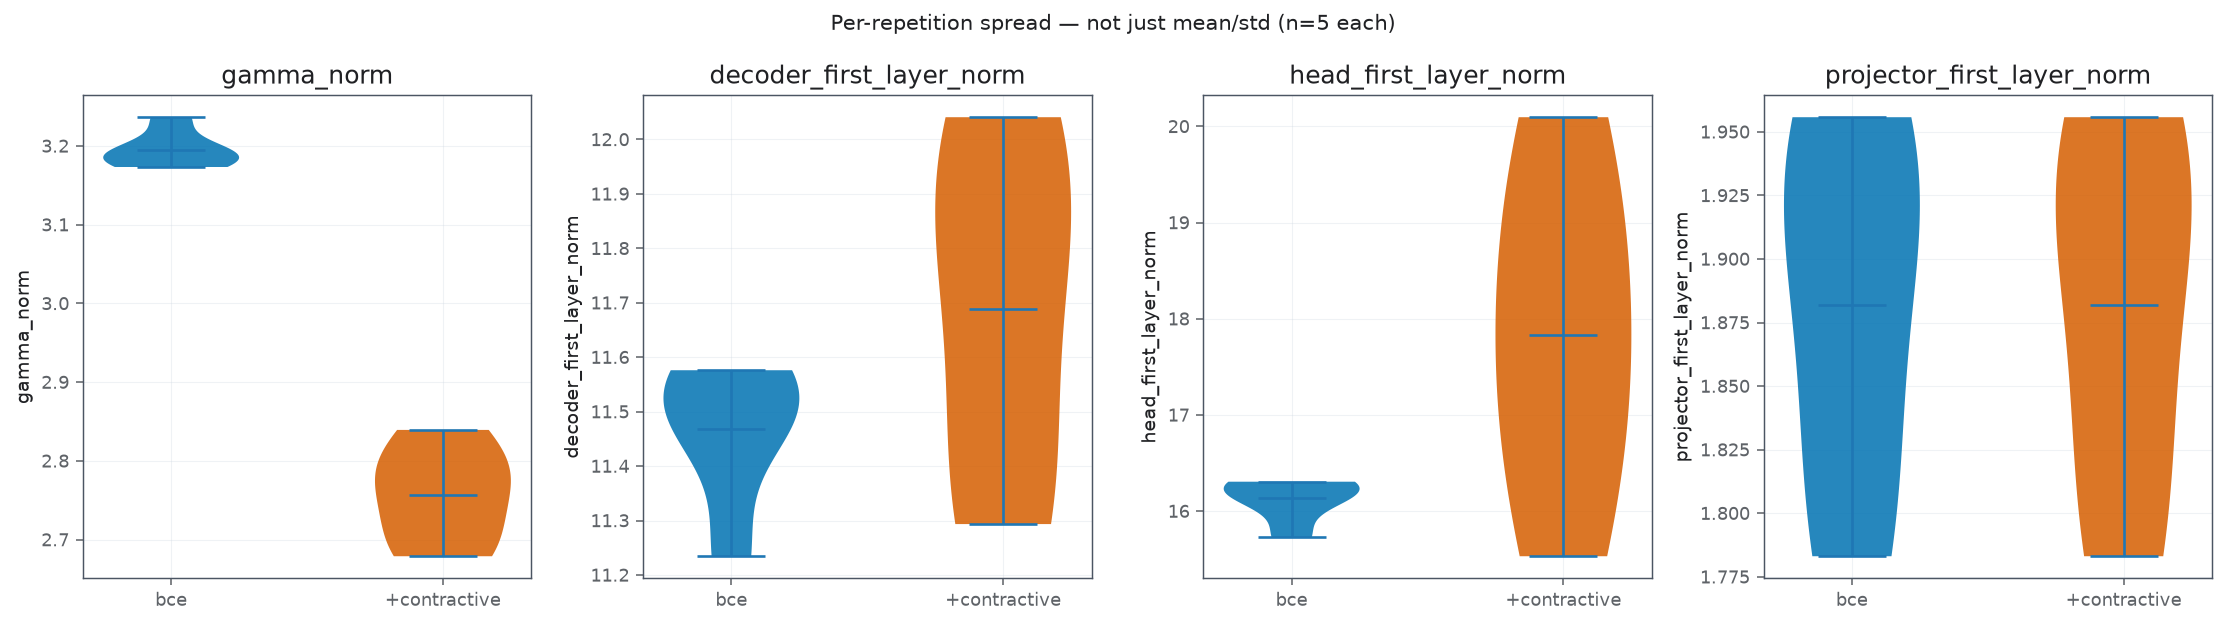

In [13]:
metric_names = ["gamma_norm", "decoder_first_layer_norm", "head_first_layer_norm", "projector_first_layer_norm"]
objectives = list(GRID_ID_BY_OBJECTIVE)
labels = [OBJECTIVE_LABELS[objective] for objective in objectives]

figure, axes = plt.subplots(1, len(metric_names), figsize=(4.0 * len(metric_names), 4.5), dpi=theme.figure_dpi)
for axis, metric_name in zip(axes, metric_names):
    samples = [norm_frame.loc[norm_frame["objective"] == label, metric_name] for label in labels]
    parts = axis.violinplot(samples, showmeans=True, showextrema=True)
    for body, index in zip(parts["bodies"], range(len(labels))):
        body.set_facecolor(theme.color_for_model(labels[index], index))
        body.set_alpha(theme.primary_alpha)
    axis.set_xticks(range(1, len(labels) + 1))
    axis.set_xticklabels(labels)
    axis.set(ylabel=metric_name, title=metric_name)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.suptitle("Per-repetition spread — not just mean/std (n=5 each)", fontsize=11)
figure.tight_layout()

## Pre-normalization contrast distribution σ(a(x)) across objectives

### Methodology
#### Theoretical
- Tests §6.2's testable prediction: the contractive penalty's $1/\sigma^2$ factor
  implicitly pushes the encoder toward higher-contrast pre-normalization codes, so
  `bce_contractive`'s $\sigma(a(x))$ distribution should sit higher / have a lighter
  left tail than `bce`'s if that prediction holds, where $a(x)$ is the encoder's
  pre-`LayerNorm` linear output.

#### Implementation
- `encode_pre_norm_sigma(model, spectra)` registers a forward hook on
  `model.encoder.bottleneck_layer[1]` to capture that layer's output $a(x)$, then
  computes `a(x).std(dim=1, unbiased=False)` per sample (population std, `ddof=0`,
  matching `LayerNorm`'s own definition, `../report/geometria_latentu.md` §2.1) in
  batches of `BATCH_SIZE = 256`. Computed for all 10 models, on each of
  train/validation/test separately (`sample_spectra_by_split`), for the same
  reason as Check 0/Check 1.
- Plotted as a pooled (across the 5 repetitions), density-normalized step histogram
  (`ax.hist(..., density=True, histtype="step", bins=60)`) per objective, faceted by
  split. Summarized per (objective, repetition, split) as `mean_sigma` and
  `p05_sigma` (5th percentile), aggregated with `.agg(["mean", "std"])`.

### Notes
- `mean_sigma` direction (`+contractive` > `bce`) holds on every split: test
  5.44 vs. 2.09, train 6.62 vs. 2.60, validation 5.74 vs. 2.19 — matches the
  predicted direction everywhere, not only on the split originally checked.
- `p05_sigma` (lower-tail contrast) is likewise higher for `+contractive` on every
  split (test 4.14 vs. 1.74, train 4.03 vs. 1.81, validation 4.94 vs. 1.89),
  consistent with a lighter left tail as predicted, not just a shifted mean.
- `+contractive`'s `mean_sigma` is highest on `train` (6.62) and lowest on `test`
  (5.44) — same train>validation>test ordering seen in the angular-sensitivity
  section, again shared by both objectives rather than specific to the
  contractive penalty.


In [14]:
def encode_pre_norm_sigma(model, spectra: np.ndarray) -> np.ndarray:
    device = next(model.parameters()).device
    captured = {}

    def hook(_module, _input, output):
        captured["a"] = output.detach()

    handle = model.encoder.bottleneck_layer[1].register_forward_hook(hook)
    sigmas = []
    with torch.no_grad():
        for start in range(0, len(spectra), BATCH_SIZE):
            batch = torch.as_tensor(spectra[start : start + BATCH_SIZE], dtype=torch.float32).to(device)
            model(batch)
            sigmas.append(captured["a"].std(dim=1, unbiased=False).cpu().numpy())
    handle.remove()
    return np.concatenate(sigmas, axis=0)


sigma_by_objective_repetition = {}
for objective in GRID_ID_BY_OBJECTIVE:
    for repetition in REPETITIONS:
        for split_name in SPLITS:
            sigma_by_objective_repetition[(objective, repetition, split_name)] = encode_pre_norm_sigma(
                models[(objective, repetition)], sample_spectra_by_split[split_name]
            )

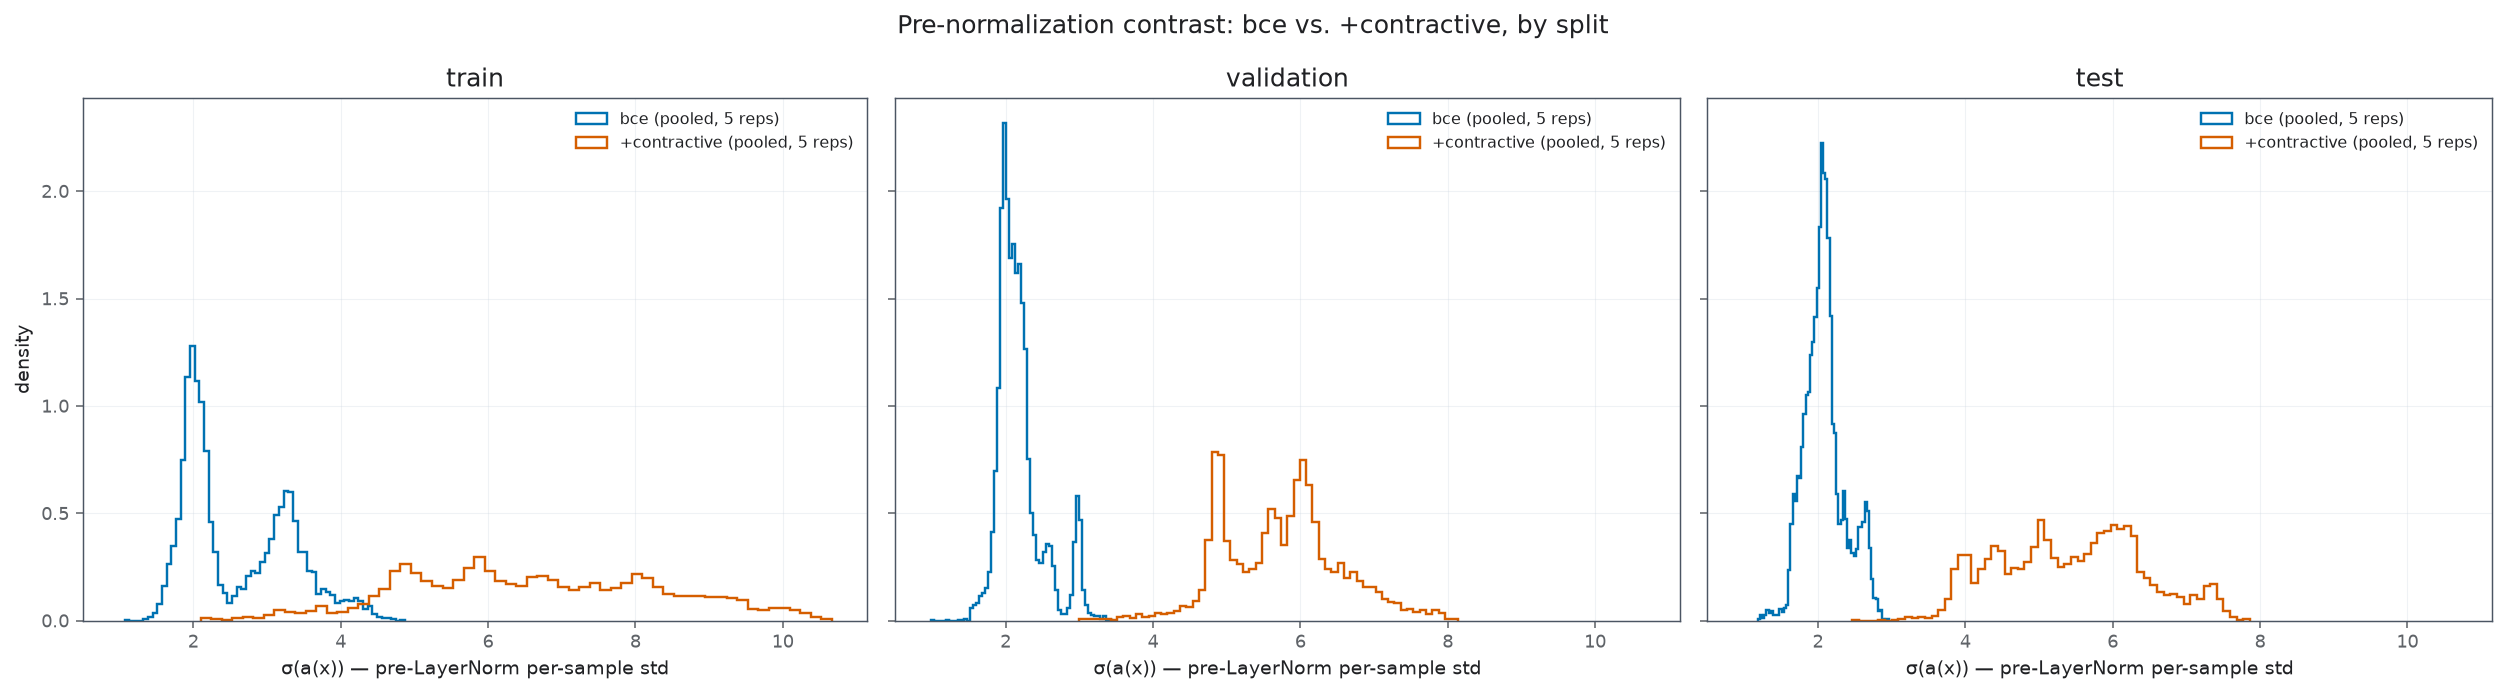

In [15]:
figure, axes = plt.subplots(1, len(SPLITS), figsize=(6.0 * len(SPLITS), 5.0), dpi=theme.figure_dpi, sharey=True, sharex=True)
for axis, split_name in zip(axes, SPLITS):
    for index, objective in enumerate(GRID_ID_BY_OBJECTIVE):
        label = OBJECTIVE_LABELS[objective]
        pooled = np.concatenate([sigma_by_objective_repetition[(objective, repetition, split_name)] for repetition in REPETITIONS])
        axis.hist(pooled, bins=60, density=True, histtype="step", color=theme.color_for_model(label, index), linewidth=theme.reconstruction_line_width, label=f"{label} (pooled, 5 reps)")
    axis.set(xlabel="σ(a(x)) — pre-LayerNorm per-sample std", ylabel="density" if split_name == SPLITS[0] else "", title=split_name)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
    axis.legend(fontsize=8, frameon=theme.legend_frame)
figure.suptitle("Pre-normalization contrast: bce vs. +contractive, by split", fontsize=13)
figure.tight_layout()

In [16]:
sigma_rows = []
for objective in GRID_ID_BY_OBJECTIVE:
    for repetition in REPETITIONS:
        for split_name in SPLITS:
            values = sigma_by_objective_repetition[(objective, repetition, split_name)]
            sigma_rows.append({
                "objective": OBJECTIVE_LABELS[objective], "repetition": repetition, "split": split_name,
                "mean_sigma": float(values.mean()), "p05_sigma": float(np.percentile(values, 5)),
            })

sigma_frame = pd.DataFrame(sigma_rows)
sigma_frame.groupby(["objective", "split"])[["mean_sigma", "p05_sigma"]].agg(["mean", "std"])

mean_sigma           p05_sigma          
                              mean       std      mean       std
objective    split                                              
+contractive test         5.438453  0.670371  4.137777  0.334645
             train        6.622374  0.771223  4.034497  0.710710
             validation   5.738812  0.686708  4.943444  0.701537
bce          test         2.090578  0.185480  1.739649  0.195630
             train        2.603707  0.168715  1.809569  0.146543
             validation   2.190148  0.226539  1.885352  0.138280

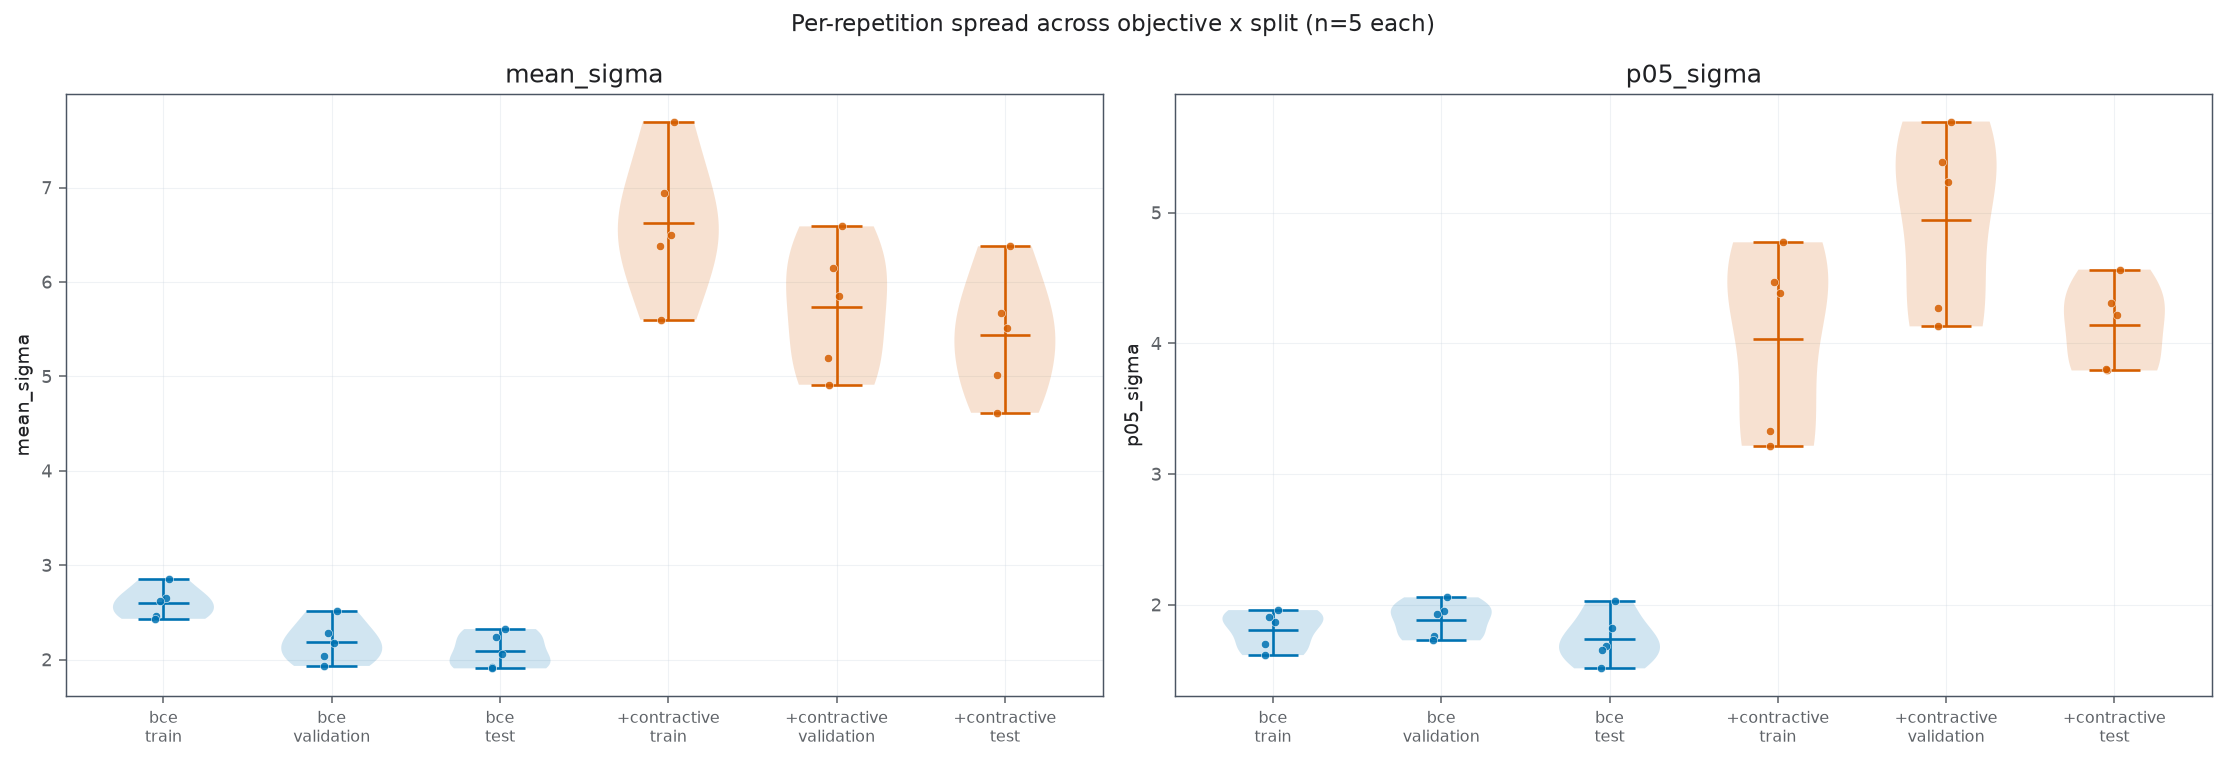

In [17]:
objectives = list(GRID_ID_BY_OBJECTIVE)
group_keys = [(objective, split_name) for objective in objectives for split_name in SPLITS]
group_labels = [f"{OBJECTIVE_LABELS[objective]}\n{split_name}" for objective, split_name in group_keys]

figure, axes = plt.subplots(1, 2, figsize=(16.0, 5.5), dpi=theme.figure_dpi)
for axis, metric_name in zip(axes, ["mean_sigma", "p05_sigma"]):
    for index, (objective, split_name) in enumerate(group_keys):
        values = sigma_frame.loc[
            (sigma_frame["objective"] == OBJECTIVE_LABELS[objective]) & (sigma_frame["split"] == split_name), metric_name
        ].to_numpy()
        plot_violin_with_points(values, position=index, ax=axis, width=0.6, color=theme.color_for_model(OBJECTIVE_LABELS[objective], objectives.index(objective)))
    axis.set_xticks(range(len(group_keys)))
    axis.set_xticklabels(group_labels, fontsize=8)
    axis.set(ylabel=metric_name, title=metric_name)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.suptitle("Per-repetition spread across objective x split (n=5 each)", fontsize=12)
figure.tight_layout()

## Perturbation trace through the pipeline — δx → δa → Pδa → δu → δz → decoder's first layer

### Methodology
#### What we want to check
- The angular-sensitivity and relative-sensitivity checks above summarize the
  encoder's overall γ-invariant sensitivity as one number per ε. This section
  decomposes that number into the actual chain of transformations a perturbation
  passes through, following exactly the recipe in
  `../report/sections/theory/part_id_05_contractive.md` §8: $\delta x \to \delta a$
  (through the pre-`LayerNorm` encoder layers) $\to P\delta a$ (after projecting out
  the two directions `LayerNorm` is provably blind to) $\to \delta u$ (the actual
  normalized-direction change) $\to \delta z$ (after the $\gamma,\beta$ affine
  transform) $\to$ the decoder's first-layer output change. Tracing every stage
  separately on real spectra shows *where* any smoothing actually happens, rather
  than only the net input-to-latent effect the earlier sections report.

#### How we measure it
- For `TRACE_SAMPLE_SIZE` real `test` spectra, across all 5 repetitions of both
  objectives: the same relative random-direction perturbation as the
  angular-sensitivity check ($\varepsilon=1.0$), $a(x)$ captured via the same
  forward hook as the $\sigma(a(x))$ check above.
- $\delta a = a(x+\delta x) - a(x)$ — exact, from two forward passes.
- $P\delta a$: $P = I - \frac1D\mathbf 1\mathbf 1^\top - \frac1Duu^\top$ (§8's exact
  projection matrix, using this spectrum's own canonicalized code $u$ — the two
  removed directions are exactly the ones `LayerNorm` is provably insensitive to:
  a uniform shift, and a pure rescaling of the centered vector).
- $\delta u = u(x+\delta x) - u(x)$, computed *exactly* via `geometry.canonicalize`
  on both forward passes — not the first-order $P\delta a/\sigma$ approximation, so
  that approximation can be checked against the true nonlinear $\delta u$ rather
  than assumed to hold.
- $\delta z = z(x+\delta x) - z(x)$, the model's own raw `latent_space` difference
  (before this project's canonicalization — this is $\S 8$'s $z$, the decoder's
  actual input).
- Decoder-first-layer output change: `model.decoder.initial_expansion[0].weight @
  δz` — exact, since a `Linear` layer's output difference under an input
  difference is exactly $W\delta z$ (the bias term cancels).
- Every quantity reported as its norm, normalized by $\lVert\delta x\rVert$, so all
  stages are on one comparable relative scale.

### Notes

- Ratio bce/+contractive grows monotonically along the pipeline and the biggest single jump is at the sigma-division step: relative_norm(delta_a) ~1.9x -> Pdelta_a ~2.5x -> delta_u ~7.8x -> delta_z ~8.9x -> decoder-first-layer output ~9.1x. Most of the gap the earlier sections report (~9x at the input-to-latent level) is already present by delta_u, i.e. it is created by dividing by sigma(a(x)), not by the projector P or the downstream decoder.
- The projector P (removing the two LayerNorm-blind directions) only modestly shrinks bce's delta_a (22.06 -> 18.87, ~15%) and +contractive's (11.71 -> 7.65, ~35%) — it narrows the gap slightly rather than creating it, consistent with P being a fixed-rank geometric operation, not an objective-dependent one.
- The decoder's first linear layer applies essentially the SAME gain to both objectives: 4.06x for bce (10.51 -> 42.70) vs. 3.98x for +contractive (1.18 -> 4.70). The decoder does not additionally amplify or compensate for the encoder-side difference — whatever gap exists at delta_z passes through to the decoder input unchanged.
- Conclusion: the contractive penalty's flattening effect is concentrated almost entirely in LayerNorm's own sigma(a(x)) normalization (a larger, more stable sigma under +contractive divides perturbations down far more than bce's smaller, more volatile sigma — matching the sigma(a(x)) distribution comparison above), not in the projector P or in any downstream (decoder/head) compensation.


In [18]:
TRACE_SAMPLE_SIZE = 50
trace_rng = np.random.default_rng(RANDOM_SEED + 3)


def encode_stage_values(model, spectrum_tensor: torch.Tensor) -> tuple[np.ndarray, np.ndarray]:
    device = next(model.parameters()).device
    captured = {}

    def hook(_module, _input, output):
        captured["a"] = output.detach()

    handle = model.encoder.bottleneck_layer[1].register_forward_hook(hook)
    with torch.no_grad():
        outputs = model(spectrum_tensor.unsqueeze(0).to(device))
    handle.remove()
    a_value = captured["a"].squeeze(0).cpu().numpy().astype(np.float64)
    z_value = outputs["latent_space"].squeeze(0).cpu().numpy().astype(np.float64)
    return a_value, z_value


trace_rows = []
for objective in GRID_ID_BY_OBJECTIVE:
    for repetition in REPETITIONS:
        model = models[(objective, repetition)]
        gamma, beta = geometry.encoder_layer_norm_parameters(model)
        dimension = gamma.shape[0]
        ones_direction = np.ones(dimension) / np.sqrt(dimension)
        decoder_weight = model.decoder.initial_expansion[0].weight.detach().cpu().numpy().astype(np.float64)

        for spectrum in sample_spectra_by_split["test"][:TRACE_SAMPLE_SIZE]:
            spectrum_tensor = torch.as_tensor(spectrum, dtype=torch.float32)
            direction = trace_rng.standard_normal(spectrum_tensor.shape)
            direction = direction / np.linalg.norm(direction)
            delta_x = 1.0 * float(np.linalg.norm(spectrum)) * direction
            perturbed_tensor = spectrum_tensor + torch.as_tensor(delta_x, dtype=torch.float32)

            a_clean, z_clean = encode_stage_values(model, spectrum_tensor)
            a_perturbed, z_perturbed = encode_stage_values(model, perturbed_tensor)

            u_clean = geometry.canonicalize(z_clean[None, :], gamma, beta)[0]
            u_perturbed = geometry.canonicalize(z_perturbed[None, :], gamma, beta)[0]

            projection_matrix = np.eye(dimension) - np.outer(ones_direction, ones_direction) - np.outer(u_clean, u_clean) / dimension
            delta_a = a_perturbed - a_clean
            delta_a_projected = projection_matrix @ delta_a
            delta_u = u_perturbed - u_clean
            delta_z = z_perturbed - z_clean
            delta_decoder_output = decoder_weight @ delta_z

            norm_delta_x = float(np.linalg.norm(delta_x))
            trace_rows.append({
                "objective": OBJECTIVE_LABELS[objective], "repetition": repetition,
                "relative_norm_delta_a": float(np.linalg.norm(delta_a)) / norm_delta_x,
                "relative_norm_projected_delta_a": float(np.linalg.norm(delta_a_projected)) / norm_delta_x,
                "relative_norm_delta_u": float(np.linalg.norm(delta_u)) / norm_delta_x,
                "relative_norm_delta_z": float(np.linalg.norm(delta_z)) / norm_delta_x,
                "relative_norm_decoder_first_layer": float(np.linalg.norm(delta_decoder_output)) / norm_delta_x,
            })
    print(f"{objective}: traced {TRACE_SAMPLE_SIZE} spectra x 5 repetitions")

trace_frame = pd.DataFrame(trace_rows)
trace_stage_names = [
    "relative_norm_delta_a", "relative_norm_projected_delta_a", "relative_norm_delta_u",
    "relative_norm_delta_z", "relative_norm_decoder_first_layer",
]
trace_frame.groupby("objective")[trace_stage_names].agg(["mean", "std"])

bce: traced 50 spectra x 5 repetitions


bce_contractive: traced 50 spectra x 5 repetitions


relative_norm_delta_a           relative_norm_projected_delta_a  \
                              mean       std                            mean   
objective                                                                      
+contractive             11.713894  6.226552                        7.645618   
bce                      22.056659  6.698122                       18.868466   

                       relative_norm_delta_u           relative_norm_delta_z  \
                   std                  mean       std                  mean   
objective                                                                      
+contractive  3.204859              1.325844  0.566785              1.179471   
bce           6.247778             10.351574  3.213337             10.506790   

                       relative_norm_decoder_first_layer             
                   std                              mean        std  
objective                                                            
+contractive  0.511390                          4.697176   2.078860  
bce           3.274797                         42.697620  14.867034

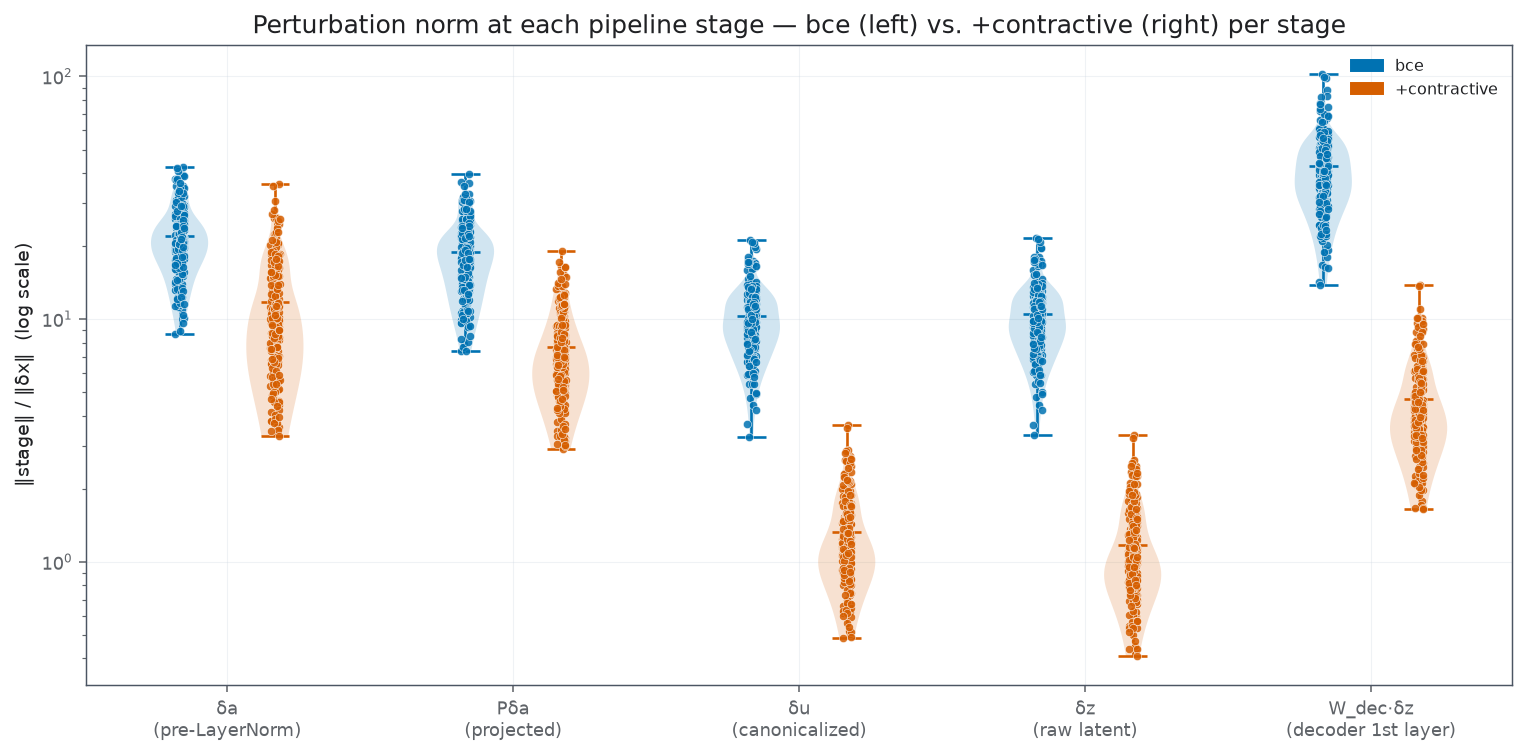

In [19]:
stage_labels = ["δa\n(pre-LayerNorm)", "Pδa\n(projected)", "δu\n(canonicalized)", "δz\n(raw latent)", "W_dec·δz\n(decoder 1st layer)"]
objectives = list(GRID_ID_BY_OBJECTIVE)

figure, axis = plt.subplots(figsize=(11.0, 5.5), dpi=theme.figure_dpi)
for stage_index, stage_name in enumerate(trace_stage_names):
    for objective_index, objective in enumerate(objectives):
        label = OBJECTIVE_LABELS[objective]
        values = trace_frame.loc[trace_frame["objective"] == label, stage_name].to_numpy()
        position = stage_index * (len(objectives) + 1) + objective_index
        plot_violin_with_points(values, position=position, ax=axis, width=0.6, color=theme.color_for_model(label, objective_index))

tick_positions = [stage_index * (len(objectives) + 1) + 0.5 for stage_index in range(len(trace_stage_names))]
axis.set_xticks(tick_positions)
axis.set_xticklabels(stage_labels)
axis.set_yscale("log")
axis.set(ylabel="‖stage‖ / ‖δx‖  (log scale)", title="Perturbation norm at each pipeline stage — bce (left) vs. +contractive (right) per stage")
axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
from matplotlib.patches import Patch
axis.legend(handles=[Patch(color=theme.color_for_model(OBJECTIVE_LABELS[o], i), label=OBJECTIVE_LABELS[o]) for i, o in enumerate(objectives)], fontsize=8, frameon=theme.legend_frame)
figure.tight_layout()

## Notes for the next pass

**Verdict, revised after adding Check 0 (pipeline correctness): the penalty
produces its intended local-flatness effect, but Check 0 surfaces a real,
separate concern that changes how positively to read that effect.**

- **Check 0 — pipeline correctness.** `cosine_with_constant_direction = 1.0`
  exactly for both objectives — canonicalization is verified correct.
  `cosine_with_inverse_gamma` is *also* near 1 (0.997-0.999) for both, which at
  first looks like the canonicalization bug the check is designed to catch — it
  is not: it means $\gamma$'s own components have low relative spread for these
  trained models, so $1/\gamma$ happens to sit close to the constant direction
  too, independent of any bug (the exact 1.0 on the constant-direction check
  already rules out the bug directly). Not a finding, just a reason this
  particular check reads less cleanly than its docstring example.
- **`cloud_asymmetry` is the real new finding, and it is concerning.**
  `+contractive`'s $\lVert\bar u\rVert^2/D = 0.964$ (std 0.006) — within 4% of
  the theoretical maximum of 1 (which is only reached if every single code is
  identical) — vs. `bce`'s $0.424$ (std 0.049). The `+contractive` encoder has
  not just become locally flatter (Check 1); its codes across *different* test
  pixels have collapsed to nearly the same point on the sphere. This reframes
  Check 1's $7.6\times$ sensitivity reduction: some of that may simply reflect
  "there is nowhere else to go" rather than a well-distributed representation
  that also happens to be locally smooth. This is exactly the kind of result
  `part_5`/`part_6` (reconstruction/prediction with `+contractive` folded in)
  need to be read against — if reconstruction/classification quality drops for
  `+contractive`, this collapse is the first place to look for why.
- **Identical `projector_first_layer_norm` across `bce` and `+contractive` is
  expected, not a bug.** Neither objective includes the contrastive
  (`InfoNCELoss`) term, so the projector's output (`projection`) never
  contributes to either loss — it is never trained, stays at its random
  initialization, and both objectives share the same `model_initialization`
  seed per repetition (`report/methodology.md` §6). This comparison becomes
  informative once `peak_random`/`peak_label_invariant`/the `grid_0004+`
  ablations (which *do* train the projector) enter the picture.
- **Angular sensitivity — dramatic, non-overlapping**, unchanged from the
  original pass: `+contractive` mean $3.76°$ vs. `bce` mean $28.80°$ at
  $\varepsilon{=}1.0$, zero overlap across 5 repetitions each. Still a real,
  $\gamma$-invariant effect (computed on $u$) — just now understood alongside
  the collapse finding above, not in isolation.
- **$\gamma$-degeneracy is present, but partial**, and does not by itself
  explain Check 1 (computed on $u$, which divides $\gamma$ out): smaller
  `gamma_norm` (2.76 vs. 3.20) paired with larger decoder/head first-layer norms
  (11.7 vs. 11.5; 17.8 vs. 16.1) for `+contractive`. A real, separate phenomenon
  alongside the intended effect — the reason $\lVert J \rVert_F$ on raw $z$
  must never be reported as a flatness number for this ablation.
- **$\sigma(a(x))$ confirms the theoretical prediction cleanly** — pooled means
  5.41 (`+contractive`) vs. 2.09 (`bce`), visibly non-overlapping histograms,
  matching `geometria_latentu.md`'s prediction that the penalty pushes toward
  higher-contrast pre-normalization codes.

**Consequence for the next notebooks**: `+contractive` genuinely changes the
encoder — both the intended way (flatter locally) and in a way that was not the
stated goal (representation collapse across samples). `part_5`/`part_6`'s
reconstruction/classification comparisons, now expanded to include `grid_0001`,
are the direct test of whether the collapse costs more than the flatness gains —
go in expecting that possibility explicitly, not just checking whether
`+contractive` "helps." Every comparison should use all 5 repetitions and an
explicit within-ablation null check from the start, per `part_7`'s lesson.
